In [5]:
import mpmath as mp
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
import time
from scipy.integrate import solve_ivp

def initialize_plotting():
    import matplotlib as mpl
    %config InlineBackend.figure_format = 'svg'
    label_size = 20
    mpl.rcParams['xtick.labelsize'] = label_size
    mpl.rcParams['ytick.labelsize'] = label_size
    mpl.rcParams['legend.fontsize'] = 14
    plt.rc('font', family='serif')
    mpl.rcParams.update({'font.size': 16})
    mpl.rcParams['text.usetex'] = False
    mpl.rcParams['figure.dpi'] = 120
initialize_plotting()


In [11]:
def steps_rk4(f, t, y, dt, args=()):
    # para una edo dy/dt = f(t, y, *args)
    # f: funcion, t: tiempo, y: estado actual, dt: paso de tiempo; args: parametros extra para f
    # definimos los pasos a promediar
    k1 = f(t, y, *args)
    k2 = f(t + 0.5*dt, y + 0.5*dt*k1, *args)
    k3 = f(t + 0.5*dt, y + 0.5*dt*k2, *args)
    k4 = f(t + dt, y + dt*k3, *args)

    y_1 = y + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
    return y_1
def detuning(alpha, t):
    # Función para definir el detuning
    return alpha * t
def d_dt_detuning(alpha, t):
    # derivada del detuning
    return alpha
def exact_equation(t, state, gamma_0, lamda, alpha):
    # state: vector con [u(t), u_punto(t)], gamma_0, lamda: param. loretziana , alpha: param. detuning
    u = state[0]
    u_dot = state[1]

    delta = detuning(alpha, t)
    delta_dot = d_dt_detuning(alpha, t)

    #armamos el Q(t) la Ec.19 en informe (ddot(u) + Q(t) u = 0)
    Q_t = ((gamma_0 * lamda) / 2.0) - (0.25 * (lamda + 1j * delta)**2) - ((1j / 2.0) * delta_dot)

    #las ecuaciones de 1er orden

    dy1_dt = u_dot 
    dy2_dt = -Q_t * u 
    return np.array([dy1_dt, dy2_dt], dtype = complex )
def dinamica_rk4(t_max, dt, u0, u_dot0, gamma_0, lamda, alpha):
    t_arr = np.arange(0, t_max, dt) # partición del intervalo
    n_steps = len(t_arr)  # cantidad de pasos
    state_arr = np.zeros((n_steps, 2), dtype = complex) # matriz vacía para guardar pasos de u y upunto
    state_arr[0] = np.array([u0, u_dot0], dtype = complex) # introducimos cond inic
    args_fis = (gamma_0, lamda, alpha) #param. fisicos del sistema

    for i in range(n_steps - 1):
        t_inst = t_arr[i]
        state_inst = state_arr[i]
        state_next = steps_rk4(exact_equation, t_inst, state_inst, dt, args_fis)
        state_arr[i+1] = state_next
    u_t = state_arr[:, 0]
    return t_arr, u_t    
    

In [12]:
# Definimos parámetros del sistema
t_max = 15.0
dt = 0.01
gamma_0 = 0.5
lamda = 1.5 
alpha = 1.0

# Definimos condiciones iniciales de u
u0 = 1.0 + 0j
u_dot0 = (lamda / 2.0) + 0j
estado_inicial = np.array([u0, u_dot0], dtype=complex)
args_sist = (gamma_0, lamda, alpha)

# aplicamos el rk4 
tiempos, u_rk4 = dinamica_rk4(t_max, dt, u0, u_dot0, gamma_0, lamda, alpha)

# calculamos la probabilidad de c1 con rk4
prob_rk4 = np.abs(u_rk4)**2 * np.exp(-lamda * tiempos)

#calculamos prob con rk45

sol_rk45 = solve_ivp(
    fun=exact_equation,
    t_span=(0, t_max),
    y0=estado_inicial,
    method='RK45',
    t_eval=tiempos,
    args=args_sist,
)
u_rk45 = sol_rk45.y[0]
prob_rk45 = np.abs(u_rk45)**2 * np.exp(-lamda * tiempos)

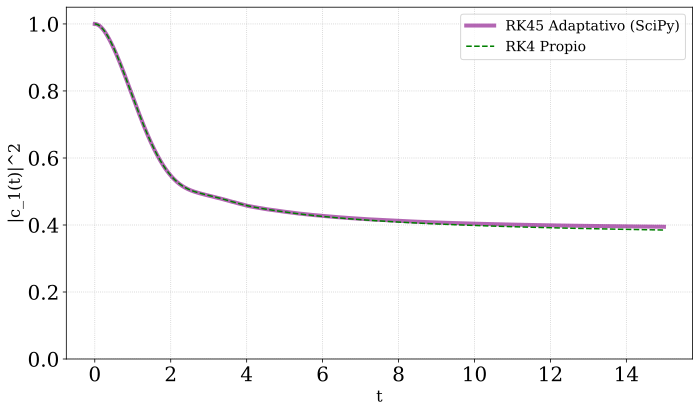

In [14]:
# Graficamos

plt.figure(figsize=(10,6))

#grafico rk45 (libreria)
plt.plot(tiempos, prob_rk45, label='RK45 Adaptativo (SciPy)', color='purple', linewidth=4, alpha=0.6)
#grafico rk4 (propio)
plt.plot(tiempos, prob_rk4, label='RK4 Propio', color='green', linewidth = 1.5, linestyle='--')

plt.xlabel('t')
plt.ylabel('|c_1(t)|^2')
plt.ylim([0, 1.05])
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()